In [1]:
import kagglehub
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import math

c:\Users\computer\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("patelris/steam-top-1495-games-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\computer\.cache\kagglehub\datasets\patelris\steam-top-1495-games-dataset\versions\9


In [3]:
data = pd.read_csv("C:/Users/computer/.cache/kagglehub/datasets/patelris/steam-top-1495-games-dataset/versions/9/steam_top_games_2026.csv")

In [4]:
df = data.copy()
df.shape

(1495, 29)

In [5]:
df.head()

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,metacritic_score,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,"Single-player, Multi-player, Co-op, Online Co-...","RPG, Open World, Survival, Co-op, Online Co-Op...",True,False,False,NaN,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy","Single-player, Steam Trading Cards, Family Sha...","RPG, Strategy, Turn-Based, Classic, Horror, Po...",True,True,True,NaN,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie","Single-player, Steam Achievements, Steam Tradi...","Indie, Adventure, Visual Novel",True,True,False,NaN,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation","Single-player, Family Sharing","Simulation, Casual, RPG, Indie, Word Game, Idler",True,False,False,NaN,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud...","Simulation, Casual, Indie, Trains, First-Perso...",True,False,False,68.0,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


In [6]:
df.columns

Index(['app_id', 'name', 'release_date', 'coming_soon', 'price_usd', 'is_free',
       'discount_pct', 'developer', 'publisher', 'genres', 'categories',
       'tags', 'platforms_win', 'platforms_mac', 'platforms_linux',
       'metacritic_score', 'recommendations', 'positive_reviews',
       'negative_reviews', 'estimated_owners', 'avg_playtime_forever',
       'avg_playtime_2weeks', 'median_playtime', 'peak_ccu', 'required_age',
       'dlc_count', 'achievements', 'short_description', 'header_image'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   app_id                1495 non-null   int64  
 1   name                  1495 non-null   object 
 2   release_date          1488 non-null   object 
 3   coming_soon           1495 non-null   bool   
 4   price_usd             1495 non-null   float64
 5   is_free               1495 non-null   bool   
 6   discount_pct          1495 non-null   int64  
 7   developer             1487 non-null   object 
 8   publisher             1483 non-null   object 
 9   genres                1487 non-null   object 
 10  categories            1486 non-null   object 
 11  tags                  1489 non-null   object 
 12  platforms_win         1495 non-null   bool   
 13  platforms_mac         1495 non-null   bool   
 14  platforms_linux       1495 non-null   bool   
 15  metacritic_score     

In [8]:
df_interface = df[["name", "short_description", "header_image"]].copy()
df_interface = df_interface.set_index("name")

In [9]:
del df["app_id"], df["short_description"], df["header_image"]

# handle NULL value

In [10]:
((df.isnull().sum() / len(df)) * 100)[df.isnull().sum() > 0]

release_date         0.468227
developer            0.535117
publisher            0.802676
genres               0.535117
categories           0.602007
tags                 0.401338
metacritic_score    63.879599
estimated_owners     0.334448
dtype: float64

In [11]:
def handleNull(df: pd.DataFrame)-> pd.DataFrame:
    """
        handle null value in df in 3 way:
        - less than 5%: del sample
        - less than 20%: fill empty with mode / median based on type
        - else: del column
    """
    df_clean = df.copy()

    null_per = ((df_clean.isnull().sum() / len(df_clean)) * 100)

    for col in df_clean.columns:
        pct = null_per[col]

        if pct > 0:
            if pct < 5:
                df_clean = df_clean.dropna(subset=[col])
                
            elif pct <= 20:
                if df_clean[col].dtype == 'object':
                    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
                else:
                    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

            else:
                df_clean = df_clean.drop(col, axis=1)
                
    return df_clean

In [12]:
df = handleNull(df)

In [13]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [14]:
df.shape

(1450, 25)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["name"].value_counts()

name
Time Gentlemen, Please! and Ben There, Dan That! Special Edition  Double Pack    2
Call of Duty®: WWII                                                              2
Mushroom Wars 2                                                                  1
The Crew™ 2                                                                      1
The Hat Man: Shadow Ward                                                         1
                                                                                ..
Zup!                                                                             1
X Rebirth                                                                        1
Conquest of Elysium 5                                                            1
Mount Your Friends                                                               1
Iron Lung                                                                        1
Name: count, Length: 1448, dtype: int64

In [17]:
df = df.sort_values(by='positive_reviews', ascending=False).reset_index(drop=True)
df = df.drop_duplicates(subset=['name'], keep='first')

In [18]:
df.head()

,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements
0,Counter-Strike 2,"Aug 21, 2012",False,0.00,True,0,Valve,Valve,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea...","FPS, Shooter, Multiplayer, Competitive, Action...",True,False,True,5037443,7642084,1173003,"100,000,000 .. 200,000,000",34018,676,6289,1013936,0,1,1
1,Rust,"Feb 8, 2018",False,39.99,False,0,Facepunch Studios,Facepunch Studios,"Action, Adventure, Indie, Massively Multiplaye...","Multi-player, MMO, PvP, Online PvP, Co-op, Onl...","Survival, Crafting, Multiplayer, Open World, O...",True,True,False,1126145,1071135,156649,"20,000,000 .. 50,000,000",20315,1157,3043,143870,0,5,102
2,Baldur's Gate 3,"Aug 3, 2023",False,59.99,False,0,Larian Studios,Larian Studios,"Adventure, RPG, Strategy","Single-player, Multi-player, Co-op, Online Co-...","RPG, Character Customization, Choices Matter, ...",True,True,False,734964,736688,23974,"20,000,000 .. 50,000,000",7794,685,4392,54771,17,2,54
3,Phasmophobia,"Sep 18, 2020",False,19.99,False,0,Kinetic Games,Kinetic Games,"Action, Indie, Early Access","Single-player, Multi-player, Co-op, Online Co-...","Horror, Online Co-Op, Multiplayer, Psychologic...",True,False,False,666253,736611,32168,"10,000,000 .. 20,000,000",2371,199,915,9978,0,0,54
4,Dead by Daylight,"Jun 14, 2016",False,19.99,False,0,Behaviour Interactive Inc.,Behaviour Interactive Inc.,Action,"Multi-player, PvP, Online PvP, Co-op, Online C...","Horror, Multiplayer, Survival Horror, Online C...",True,False,False,652542,630223,166993,"20,000,000 .. 50,000,000",13481,844,1448,44886,17,37,297


# handle columns value

In [19]:
def clean_e_owners(val):
    val = str(val).replace(',', '')
    if '..' in val:
        low, high = val.split('..')
        return (float(low) + float(high)) / 2
    return float(val)

df['estimated_owners'] = df['estimated_owners'].apply(clean_e_owners)

In [20]:
genres_df     = df["genres"].str.get_dummies(sep=", ").add_prefix("genres_").astype(bool)
categories_df = df["categories"].str.get_dummies(sep=", ").add_prefix("cat_").astype(bool)
tags_df       = df["tags"].str.get_dummies(sep=", ").add_prefix("tag_").astype(bool)

df = pd.concat([df, genres_df, categories_df, tags_df], axis=1)

del df["genres"], df["categories"], df["tags"]

In [21]:
genres     = [col for col in df.columns if col.startswith('genres_')]
categories = [col for col in df.columns if col.startswith('cat_')]
tags       = [col for col in df.columns if col.startswith('tag_')]

print(f"genres len: {len(genres)}")
print(f"categories len: {len(categories)}")
print(f"tags len: {len(tags)}")

genres len: 24
categories len: 56
tags len: 397


In [22]:
df["coming_soon"].nunique()

1

In [23]:
df["platforms_win"].nunique()

1

In [24]:
def drop_constant(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    constant_cols = []
    
    for col in df_clean.columns:
        unique_count = df_clean[col].nunique()
        
        if unique_count == 1:
            constant_cols.append(col)
            
    if constant_cols:
        df_clean = df_clean.drop(columns=constant_cols)
        
    return df_clean

In [25]:
df = drop_constant(df)

In [26]:
df['release_date'] = df['release_date'].astype(str).str.extract(r'(19\d{2}|20\d{2})')
df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')
df['release_date'] = df['release_date'].fillna(df['release_date'].median()).astype(int)

df = df.rename(columns={'release_date': 'release_year'})

In [27]:
df['price_usd'] = df['price_usd'] * 3.75
df = df.rename(columns={'price_usd': 'price_sar'})

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1448 entries, 0 to 1449
Columns: 497 entries, name to tag_e-sports
dtypes: bool(480), float64(2), int64(12), object(3)
memory usage: 882.4+ KB


In [29]:
df.head(10)

,name,release_year,price_sar,is_free,discount_pct,developer,publisher,platforms_mac,platforms_linux,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,genres_Action,genres_Adventure,genres_Animation & Modeling,genres_Casual,genres_Design & Illustration,genres_Early Access,genres_Education,genres_Free To Play,genres_Game Development,genres_Gore,genres_Indie,genres_Massively Multiplayer,genres_Nudity,genres_Photo Editing,genres_RPG,genres_Racing,genres_Simulation,genres_Software Training,genres_Sports,genres_Strategy,genres_Utilities,genres_Video Production,genres_Violent,genres_Web Publishing,cat_Adjustable Difficulty,cat_Adjustable Text Size,cat_Camera Comfort,cat_Captions available,cat_Chat Speech-to-text,cat_Chat Text-to-speech,cat_Co-op,cat_Color Alternatives,cat_Commentary available,cat_Cross-Platform Multiplayer,cat_Custom Volume Controls,cat_Family Sharing,cat_Full controller support,cat_HDR available,cat_In-App Purchases,cat_Includes Source SDK,cat_Includes level editor,cat_Keyboard Only Option,cat_LAN Co-op,cat_LAN PvP,cat_MMO,cat_Mods,cat_Mouse Only Option,cat_Multi-player,cat_Narrated Game Menus,cat_Online Co-op,cat_Online PvP,cat_Partial Controller Support,cat_Playable without Timed Input,cat_PvP,cat_Remote Play Together,cat_Remote Play on Phone,cat_Remote Play on TV,cat_Remote Play on Tablet,cat_Save Anytime,cat_Shared/Split Screen,cat_Shared/Split Screen Co-op,cat_Shared/Split Screen PvP,cat_Single-player,cat_Stats,cat_Steam Achievements,cat_Steam Cloud,cat_Steam Leaderboards,cat_Steam Timeline,cat_Steam Trading Cards,cat_Steam Workshop,cat_SteamVR Collectibles,cat_Stereo Sound,cat_Subtitle Options,cat_Surround Sound,cat_Touch Only Option,cat_Tracked Controller Support,cat_VR Only,cat_VR Support,cat_VR Supported,cat_Valve Anti-Cheat enabled,tag_1980s,tag_1990's,tag_2.5D,tag_2D,tag_2D Fighter,tag_2D Platformer,tag_360 Video,tag_3D,tag_3D Fighter,tag_3D Platformer,tag_3D Vision,tag_4 Player Local,tag_4X,tag_6DOF,tag_Abstract,tag_Action,tag_Action RPG,tag_Action RTS,tag_Action Roguelike,tag_Action-Adventure,tag_Addictive,tag_Adventure,tag_Agriculture,tag_Aliens,tag_Alternate History,tag_Ambient,tag_America,tag_Animation & Modeling,tag_Anime,tag_Arcade,tag_Arena Shooter,tag_Artificial Intelligence,tag_Assassin,tag_Asynchronous Multiplayer,tag_Atmospheric,tag_Auto Battler,tag_Automation,tag_Automobile Sim,tag_Base-Building,tag_Based On A Novel,tag_Basketball,tag_Battle Royale,tag_Beat 'em up,tag_Beautiful,tag_Benchmark,tag_Bikes,tag_Birds,tag_Blood,tag_Board Game,tag_Boomer Shooter,tag_Boss Rush,tag_Bowling,tag_Boxing,tag_Building,tag_Bullet Hell,tag_Bullet Time,tag_CRPG,tag_Capitalism,tag_Card Battler,tag_Card Game,tag_Cartoon,tag_Cartoony,tag_Casual,tag_Cats,tag_Character Action Game,tag_Character Customization,tag_Choices Matter,tag_Choose Your Own Adventure,tag_Cinematic,tag_City Builder,tag_Class-Based,tag_Classic,tag_Clicker,tag_Co-op,tag_Co-op Campaign,tag_Cold War,tag_Collectathon,tag_Colony Sim,tag_Colorful,tag_Combat,tag_Combat Racing,tag_Comedy,tag_Comic Book,tag_Competitive,tag_Conspiracy,tag_Controller,tag_Conversation,tag_Cooking,tag_Cozy,tag_Crafting,tag_Creature Collector,tag_Crime,tag_Cult Classic,tag_Cute,tag_Cyberpunk,tag_Dark,tag_Dark Comedy,tag_Dark Fantasy,tag_Dark Humor,tag_Dating Sim,tag_Deckbuilding,tag_Demons,tag_Design & Illustration,tag_Destruction,tag_Detective,tag_Difficult,tag_Dinosaurs,tag_Diplomacy,tag_Dog,tag_Dragons,tag_Drama,tag_Driving,tag_Dungeon Crawler,tag_Dungeons & Dragons,tag_Dwarf,tag_Dynamic Narration,tag_Dystopian,tag_Early Access,tag_Economy,tag_Education,tag_Emotional,tag_Epic,tag_Episodic,tag_Escape Room,tag_Experimental,tag_Exploration,tag_Extraction Shooter,tag_FMV,tag_FPS,tag_Family Friendly,tag_Fantasy,tag_Farming,tag_Farming Sim,tag_Fast-Paced,tag_Female Protagonist,tag_Fighting,tag_First-Person,tag_Fishing,tag_Flight,tag_Football (American),tag_Foot

# ..

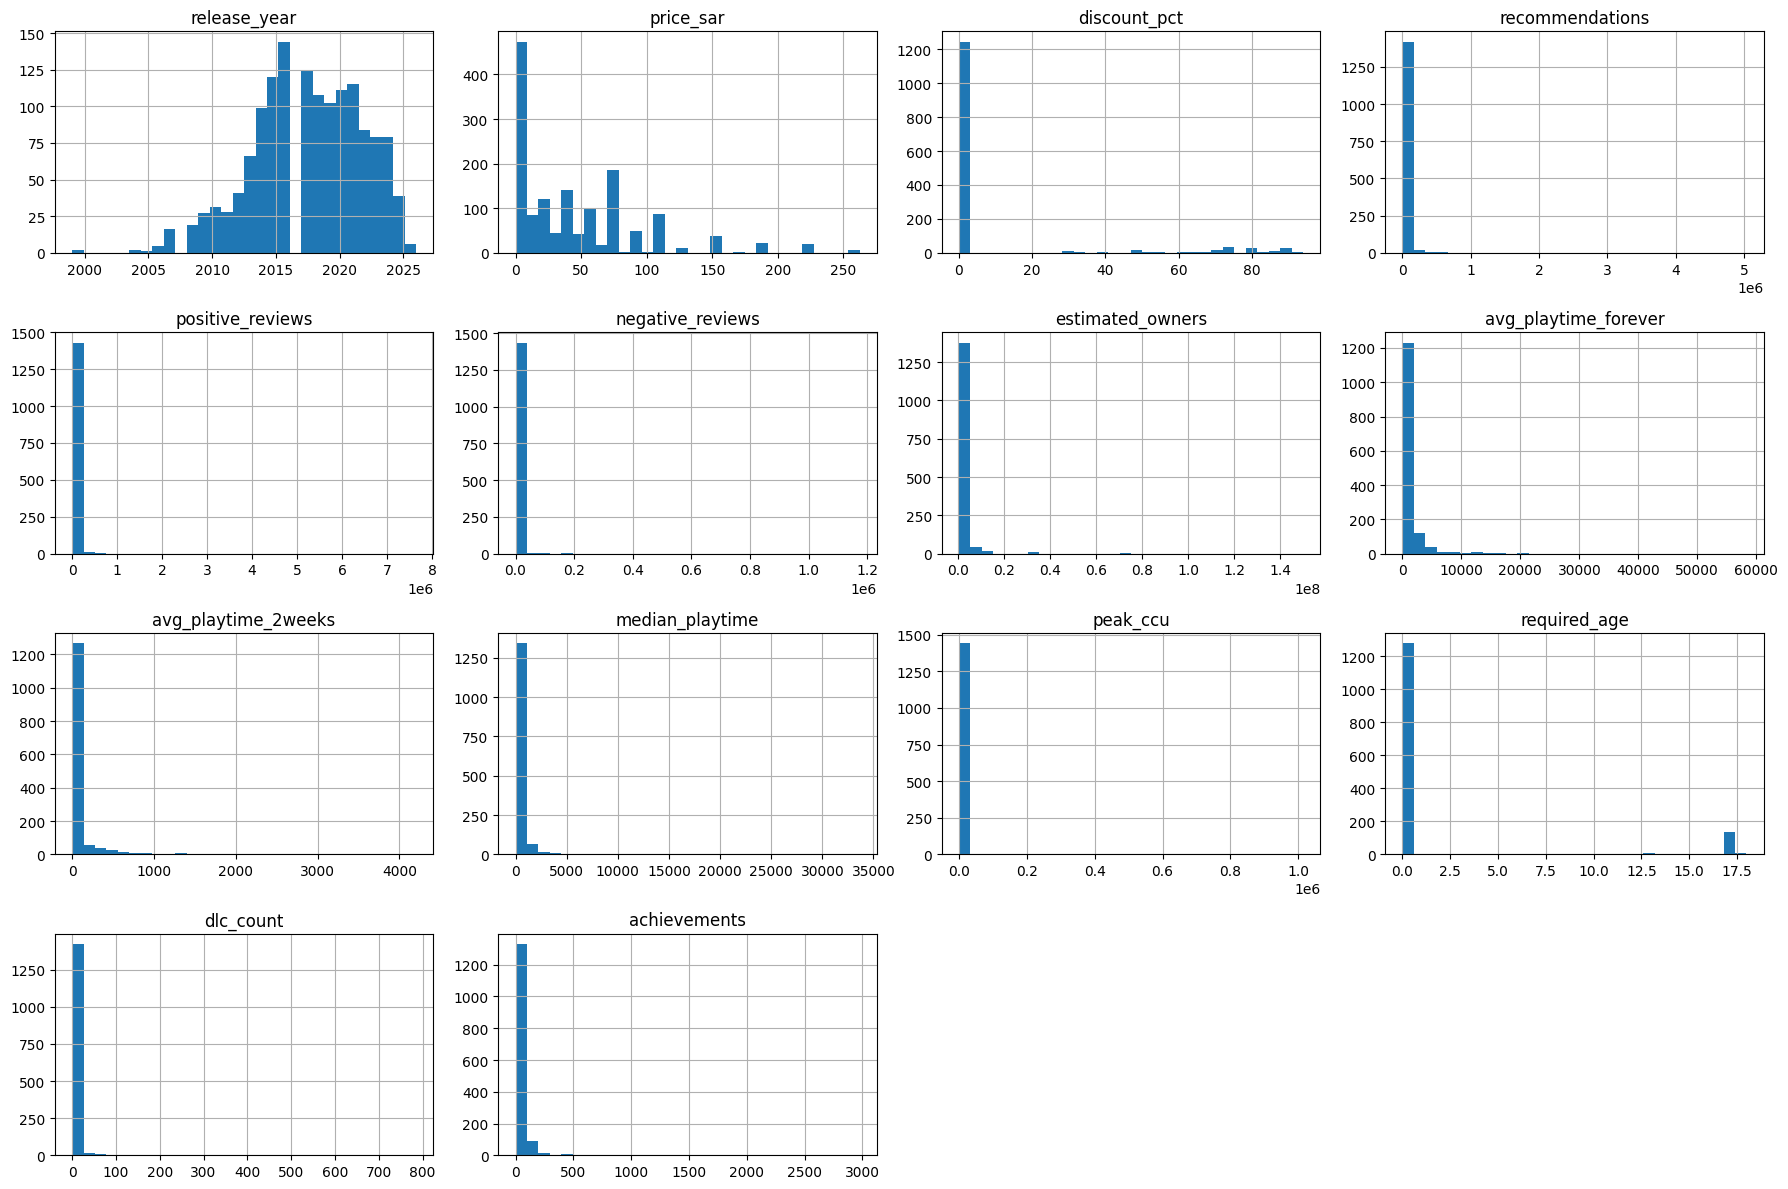

In [30]:
df.select_dtypes(include=["int64", "float64"]).hist(
    figsize=(18, 12),
    bins=30
)

plt.tight_layout()
plt.show()

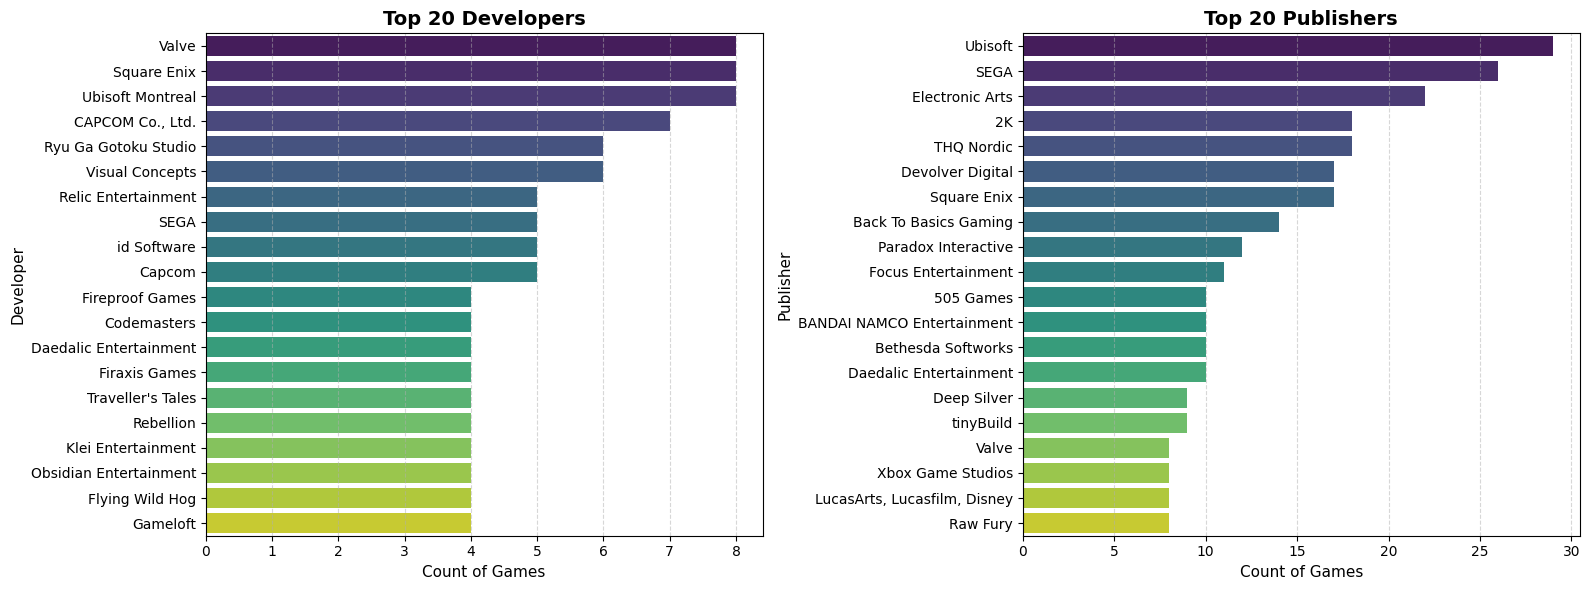

In [31]:
obj_cols = df[["developer", "publisher"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in zip(axes, obj_cols):
    top_20 = df[col].value_counts().head(20)
    sns.barplot(x=top_20.values, y=top_20.index, hue=top_20.index, palette="viridis", legend=False, ax=ax)

    ax.set_title(f'Top 20 {col.capitalize()}s', fontsize=14, fontweight='bold')
    ax.set_xlabel('Count of Games', fontsize=11)
    ax.set_ylabel(col.capitalize(), fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

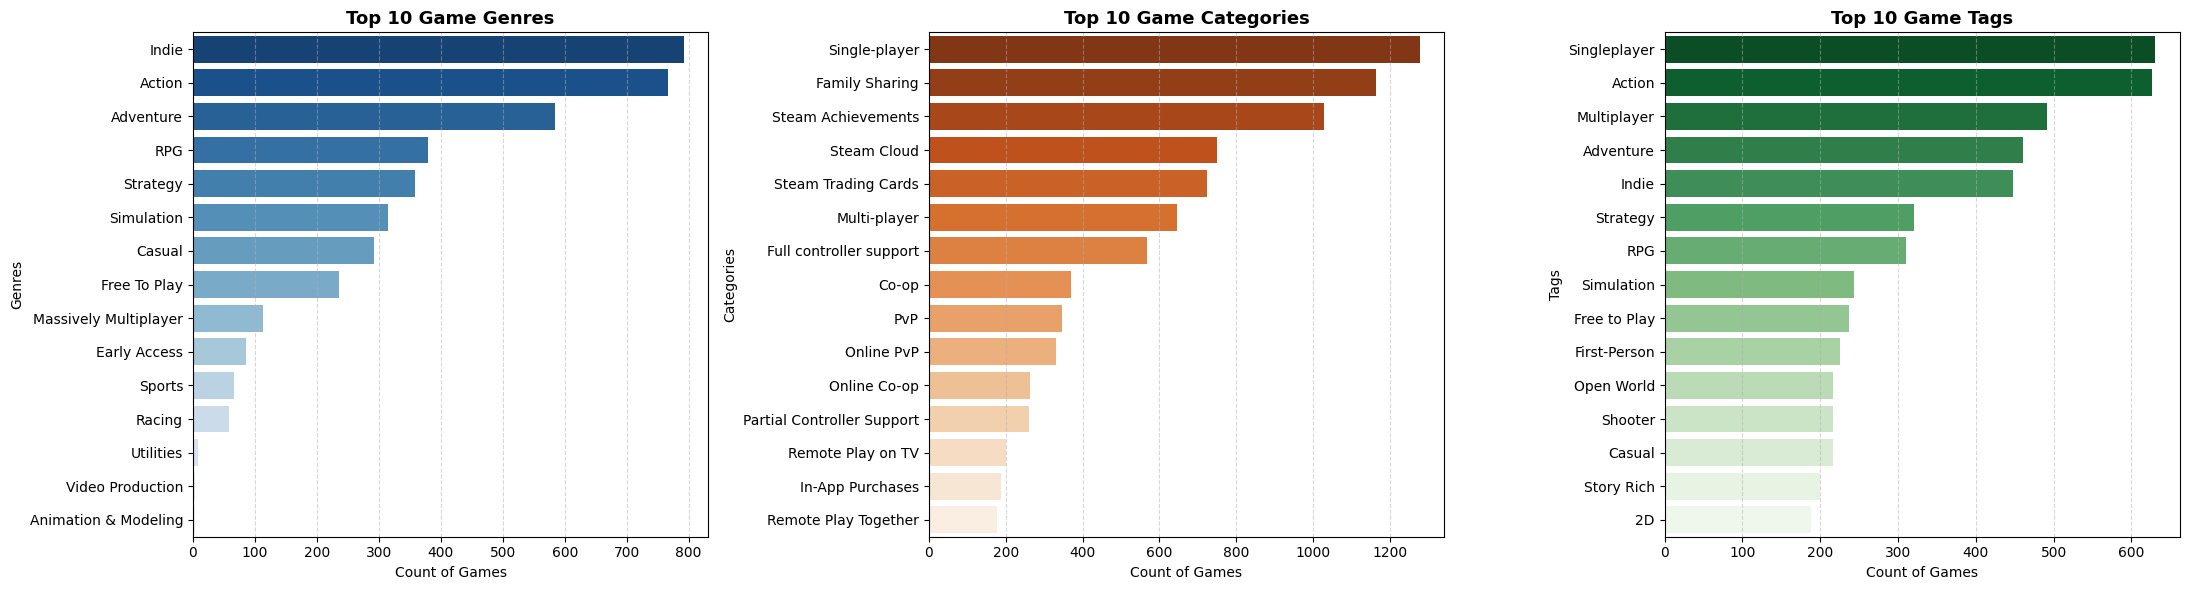

In [32]:
top_genres = df[genres].sum().sort_values(ascending=False).head(15)
top_genres.index = top_genres.index.str.replace('genres_', '')

top_cats = df[categories].sum().sort_values(ascending=False).head(15)
top_cats.index = top_cats.index.str.replace('cat_', '')

top_tags = df[tags].sum().sort_values(ascending=False).head(15)
top_tags.index = top_tags.index.str.replace('tag_', '')


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

# genres
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Game Genres', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count of Games')
axes[0].set_ylabel('Genres')

# categories
sns.barplot(x=top_cats.values, y=top_cats.index, hue=top_cats.index, palette='Oranges_r', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Game Categories', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count of Games')
axes[1].set_ylabel('Categories')

# tags
sns.barplot(x=top_tags.values, y=top_tags.index, hue=top_tags.index, palette='Greens_r', legend=False, ax=axes[2])
axes[2].set_title('Top 10 Game Tags', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Count of Games')
axes[2].set_ylabel('Tags')

for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

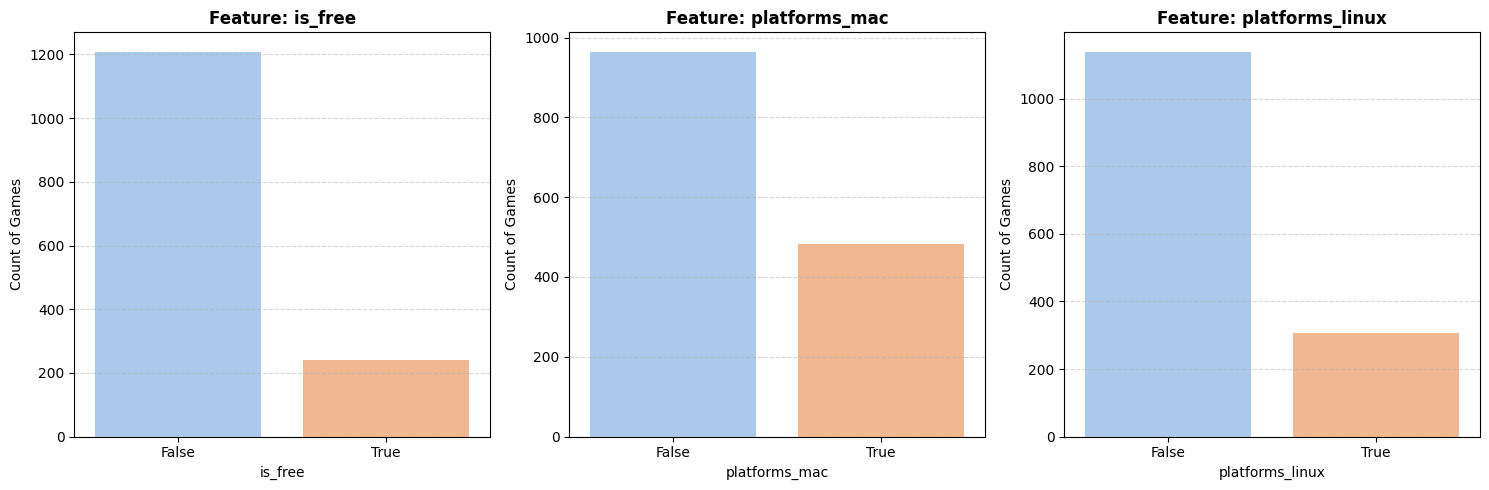

In [33]:
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

features_to_plot = [col for col in bool_cols if not (col.startswith('genres_') or col.startswith('cat_') or col.startswith('tag_'))]

n_bool_grid = len(features_to_plot)
fig, axes = plt.subplots(nrows=1, ncols=n_bool_grid, figsize=(5 * n_bool_grid, 5))

axes = axes.flatten()
    
for i, col in enumerate(features_to_plot):
    sns.countplot(data=df, x=col, hue=col, palette='pastel', legend=False, ax=axes[i])
    axes[i].set_title(f'Feature: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count of Games')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.show()

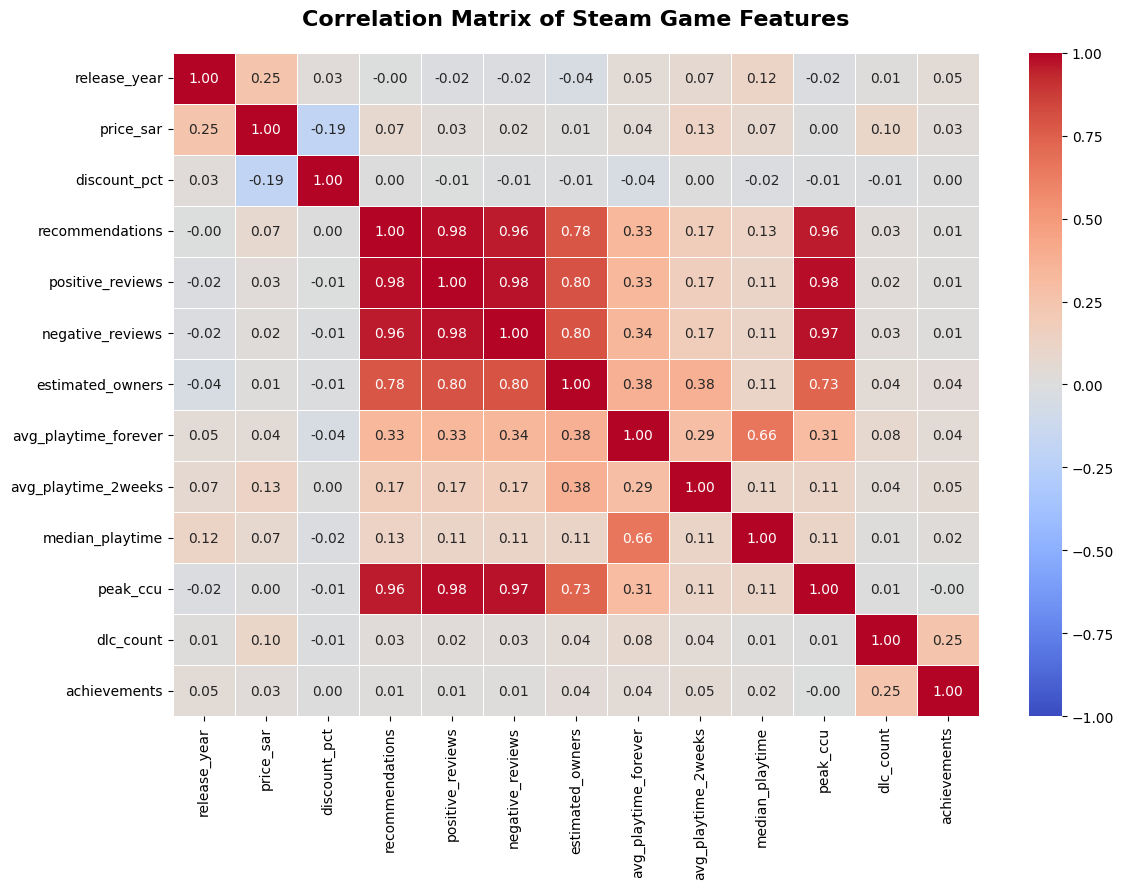

In [34]:
corr_matrix = df.select_dtypes(include=['number']).drop(columns=['required_age'], errors='ignore').corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of Steam Game Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()